# Automated Crop Disease Detection using CNNs
**Group 9 — CS464_A: Deep Learning**  
Dennis Owusu · Hutton Amison-Addy

---

This notebook trains a Convolutional Neural Network (CNN) on the **PlantVillage dataset** (color images) to classify plant leaves into one of 38 crop–disease categories. The model takes a raw RGB leaf image as input and outputs a probability distribution across all disease classes.

**Pipeline overview:**
1. Environment setup & imports
2. Dataset exploration
3. Data loading & augmentation
4. Model definition (Custom CNN + Transfer Learning with ResNet-50)
5. Training loop with validation
6. Training curves
7. Evaluation & metrics
8. Inference on a single image
9. Save & load model

## 1. Environment Setup & Imports

In [1]:
import os
import random
import time
import copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from tqdm.auto import tqdm

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device    : {DEVICE}")

PyTorch version : 1.13.0
CUDA available  : True
Using device    : cuda


In [2]:
# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

## 2. Dataset Exploration

On Kaggle the PlantVillage dataset is mounted under `/kaggle/input/`. We work with the **color** split for this phase.

In [3]:
KAGGLE_INPUT = Path("/kaggle/input")

# Find the dataset folder (contains 'color', 'grayscale', 'segmented')
DATA_ROOT = None
for folder in KAGGLE_INPUT.iterdir():
    color_candidate = folder / "color"
    if color_candidate.exists():
        DATA_ROOT = folder
        break
    # Some uploads have an extra nesting level
    for subfolder in folder.iterdir():
        if (subfolder / "color").exists():
            DATA_ROOT = subfolder
            break
    if DATA_ROOT:
        break

if DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not find the 'color' folder under /kaggle/input.\n"
        "Make sure the PlantVillage dataset is added to this notebook."
    )

DATA_DIR = DATA_ROOT / "color"
print(f"Dataset root : {DATA_ROOT}")
print(f"Color path   : {DATA_DIR}")
print(f"Contents     : {[d.name for d in DATA_ROOT.iterdir() if d.is_dir()]}")

Dataset root : /kaggle/input/plantvillage-dataset
Color path   : /kaggle/input/plantvillage-dataset/color
Contents     : ['segmented', 'grayscale', 'plantvillage dataset', 'color']


In [4]:
# ── Class names & counts
CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(f"Number of classes : {NUM_CLASSES}")
print(f"First 5           : {CLASS_NAMES[:5]}")
print(f"Last  3           : {CLASS_NAMES[-3:]}")

Number of classes : 38
First 5           : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
Last  3           : ['Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


Total images : 54,305


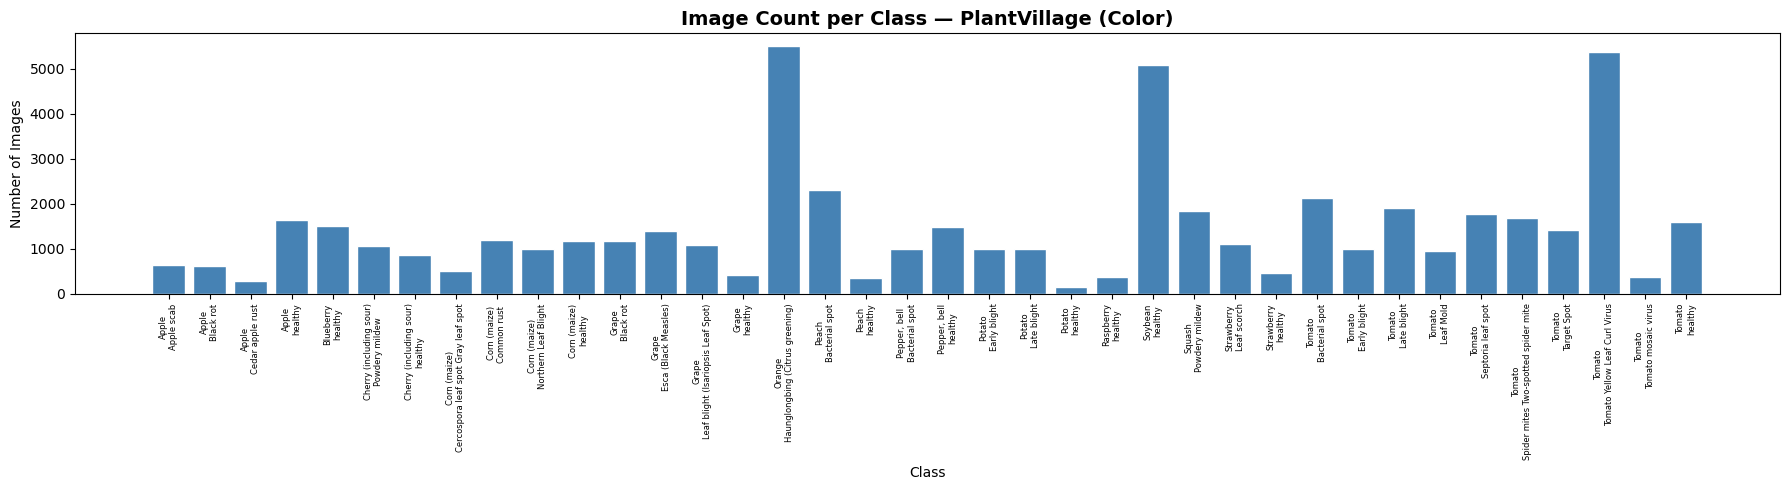

In [5]:
# ── Image count per class
class_counts = {}
for cls in CLASS_NAMES:
    imgs = []
    for ext in ("*.jpg", "*.JPG", "*.jpeg", "*.png", "*.PNG"):
        imgs.extend((DATA_DIR / cls).glob(ext))
    class_counts[cls] = len(imgs)

total_images = sum(class_counts.values())
print(f"Total images : {total_images:,}")

short_names = [c.replace("___", "\n").replace("_", " ") for c in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(short_names, [class_counts[c] for c in CLASS_NAMES],
       color="steelblue", edgecolor="white")
ax.set_title("Image Count per Class — PlantVillage (Color)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Images")
ax.set_xlabel("Class")
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

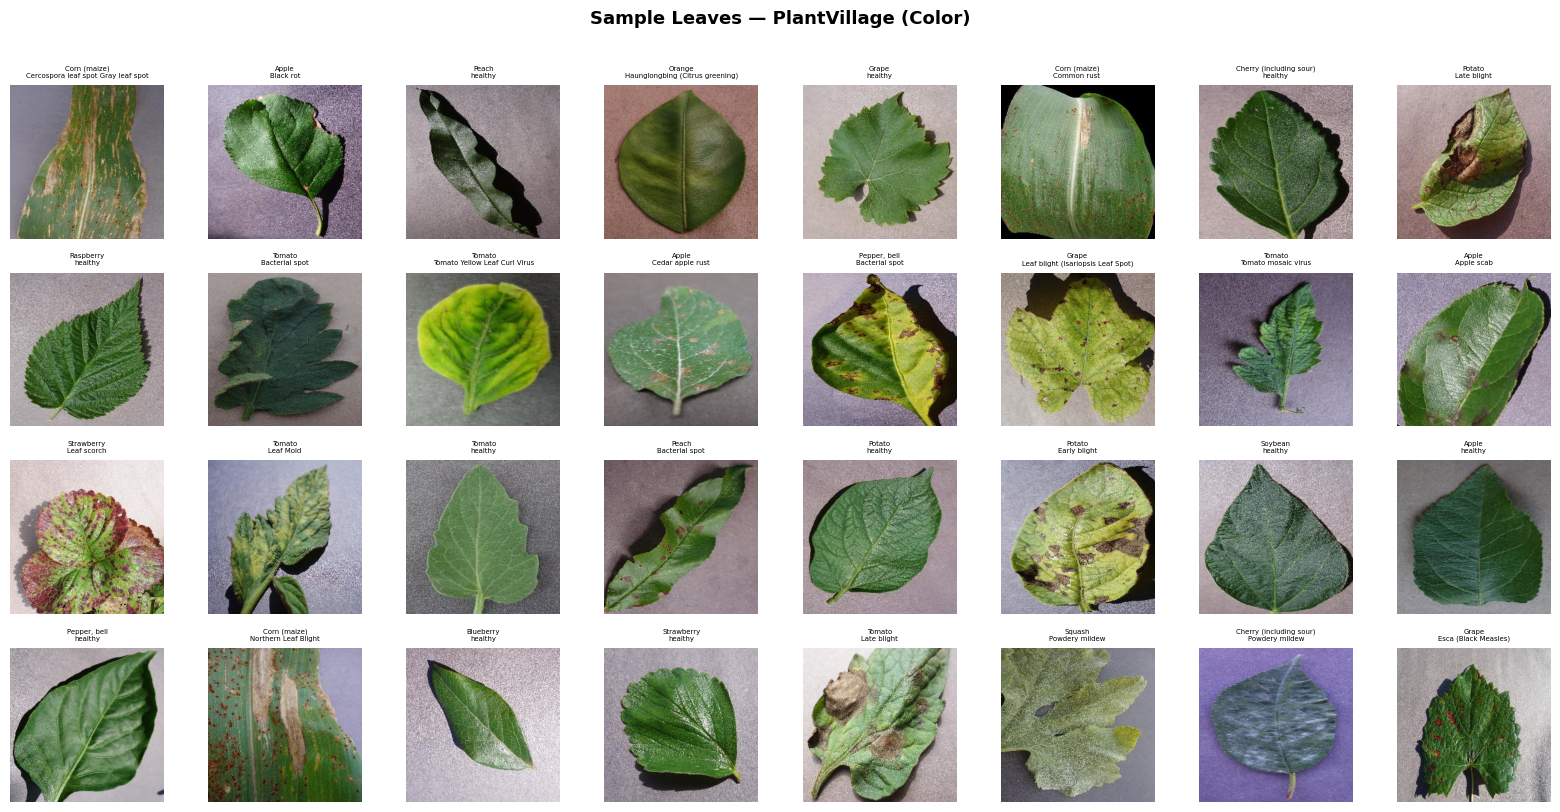

In [6]:
# ── Sample images grid
def show_sample_images(data_dir, class_names, n_per_row=8, rows=4):
    fig, axes = plt.subplots(rows, n_per_row, figsize=(n_per_row * 2, rows * 2))
    selected = random.sample(class_names, min(rows * n_per_row, len(class_names)))
    for ax, cls in zip(axes.flatten(), selected):
        imgs = []
        for ext in ("*.jpg", "*.JPG", "*.jpeg", "*.png"):
            imgs.extend((data_dir / cls).glob(ext))
        if imgs:
            img = Image.open(random.choice(imgs)).convert("RGB")
            ax.imshow(img)
        ax.set_title(cls.replace("___", "\n").replace("_", " "), fontsize=5)
        ax.axis("off")
    for ax in axes.flatten()[len(selected):]:
        ax.axis("off")
    plt.suptitle("Sample Leaves — PlantVillage (Color)",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

show_sample_images(DATA_DIR, CLASS_NAMES)

## 3. Data Loading & Augmentation

Augmentations applied during **training** only:
- `RandomResizedCrop` — scale and aspect variation
- `RandomHorizontalFlip` / `RandomVerticalFlip`
- `RandomRotation(30°)`
- `ColorJitter` — brightness, contrast, saturation
- Normalise to ImageNet statistics

**Validation/test** use only resize + center-crop + normalise.

Split: **80 % train / 10 % val / 10 % test**

In [7]:
# ── Hyper-parameters
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_EPOCHS   = 25
LR           = 1e-3
LR_STEP      = 7       # decay LR every N epochs
LR_GAMMA     = 0.1
WEIGHT_DECAY = 1e-4

TRAIN_SPLIT  = 0.80
VAL_SPLIT    = 0.10
# TEST_SPLIT = 0.10  (remainder)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print("Hyper-parameters set.")

Hyper-parameters set.


In [8]:
# ── Transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transforms defined.")

Transforms defined.


In [9]:
# ── Load dataset & split
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)

assert full_dataset.classes == CLASS_NAMES, \
    "Class list mismatch — check DATA_DIR."

print(f"Dataset loaded : {len(full_dataset):,} images | {NUM_CLASSES} classes")

n_total = len(full_dataset)
n_train = int(TRAIN_SPLIT * n_total)
n_val   = int(VAL_SPLIT   * n_total)
n_test  = n_total - n_train - n_val

generator = torch.Generator().manual_seed(SEED)
train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test], generator=generator
)

# Give val/test their own dataset copy with eval transforms (no augmentation)
val_dataset  = datasets.ImageFolder(root=DATA_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(root=DATA_DIR, transform=eval_transform)

val_set  = torch.utils.data.Subset(val_dataset,  val_set.indices)
test_set = torch.utils.data.Subset(test_dataset, test_set.indices)

print(f"Train : {len(train_set):,} | Val : {len(val_set):,} | Test : {len(test_set):,}")

Dataset loaded : 54,305 images | 38 classes
Train : 43,444 | Val : 5,430 | Test : 5,431


In [10]:
# ── DataLoaders
NUM_WORKERS = 2   # Kaggle notebooks work reliably with 2

train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_set, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_set, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"Train batches : {len(train_loader)} "
      f"| Val batches : {len(val_loader)} "
      f"| Test batches : {len(test_loader)}")

Train batches : 1358 | Val batches : 170 | Test batches : 170


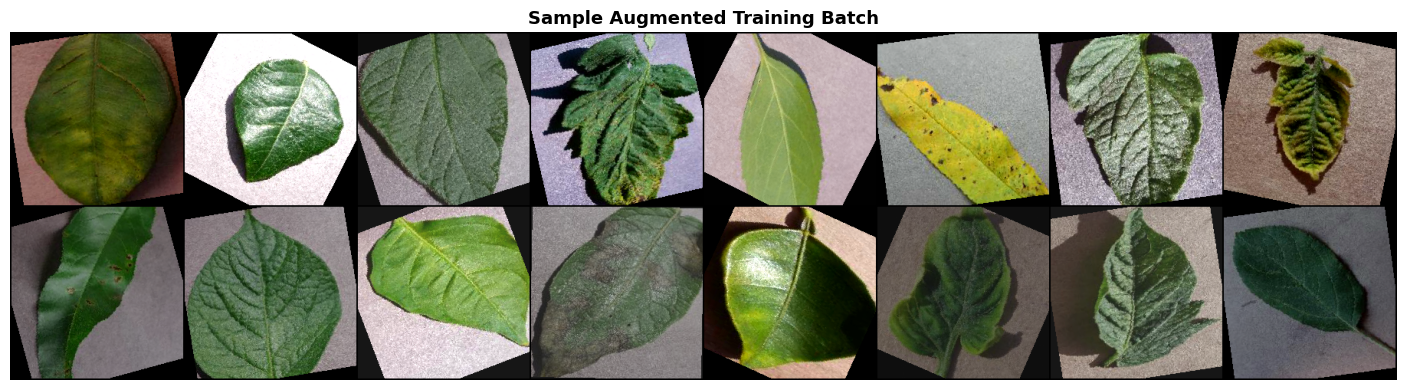

Labels: ['Orange___Haunglongbing_(Citrus_greening)', 'Blueberry___healthy', 'Soybean___healthy', 'Tomato___Septoria_leaf_spot', 'Cherry_(including_sour)___healthy', 'Peach___Bacterial_spot', 'Tomato___healthy', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus']


In [11]:
# ── Visualise an augmented training batch
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    t = tensor.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

imgs, labels = next(iter(train_loader))
n_show = min(16, len(imgs))
grid = make_grid([denormalize(imgs[i]) for i in range(n_show)],
                 nrow=8, padding=2)

plt.figure(figsize=(16, 4))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.title("Sample Augmented Training Batch",
          fontsize=13, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

print("Labels:", [CLASS_NAMES[l] for l in labels[:8].tolist()])

## 4. Model Definition

Two options — switch via `USE_PRETRAINED`:

| | Architecture | Approach |
|--|--|--|
| **A** | Custom CNN | Train from scratch |
| **B** | ResNet-50 ✅ | Transfer learning from ImageNet |

In [12]:
# ── Option A: Custom CNN ──────────────────────────────────────────────────────
class CustomCNN(nn.Module):
    """
    4-block CNN: Conv-BN-ReLU pairs → MaxPool → Global Average Pool → FC head.
    """
    def __init__(self, num_classes: int):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
            )

        self.features = nn.Sequential(
            conv_block(3,   64),   # 224→112
            conv_block(64,  128),  # 112→56
            conv_block(128, 256),  # 56→28
            conv_block(256, 512),  # 28→14
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).flatten(1)
        return self.classifier(x)


# ── Option B: ResNet-50 with Transfer Learning ────────────────────────────────
def build_resnet50(num_classes: int, fine_tune: bool = True) -> nn.Module:
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    if not fine_tune:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, num_classes)
    )
    return model


def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total parameters     : {total:,}")
    print(f"  Trainable parameters : {trainable:,}")


# Sanity-check
_x = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE)
for name, m in [("CustomCNN", CustomCNN(NUM_CLASSES)),
                ("ResNet-50", build_resnet50(NUM_CLASSES))]:
    assert m(_x).shape == (2, NUM_CLASSES)
    print(f"{name} — output shape OK")
    count_parameters(m)
del _x

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


  0%|          | 0.00/97.8M [00:00<?, ?B/s]

CustomCNN — output shape OK
  Total parameters     : 4,828,390
  Trainable parameters : 4,828,390
ResNet-50 — output shape OK
  Total parameters     : 23,585,894
  Trainable parameters : 23,585,894


In [13]:
# ── Choose your model ─────────────────────────────────────────────────────────
USE_PRETRAINED = True   # False → CustomCNN from scratch

if USE_PRETRAINED:
    model = build_resnet50(NUM_CLASSES, fine_tune=True)
    print("Model: ResNet-50 (Transfer Learning / Fine-tuning)")
else:
    model = CustomCNN(NUM_CLASSES)
    print("Model: Custom CNN (Training from Scratch)")

model = model.to(DEVICE)

Model: ResNet-50 (Transfer Learning / Fine-tuning)


## 5. Training

In [14]:
# ── Loss, Optimizer, Scheduler ────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.SGD(
    model.parameters(),
    lr=LR, momentum=0.9, weight_decay=WEIGHT_DECAY
)

# Uncomment to use Adam instead:
# optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.StepLR(
    optimizer, step_size=LR_STEP, gamma=LR_GAMMA
)

CHECKPOINT_PATH = "/kaggle/working/best_model.pth"
print("Loss / optimizer / scheduler ready.")

Loss / optimizer / scheduler ready.


In [15]:
# ── Helper: one training epoch ────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device, epoch, num_epochs):
    model.train()
    running_loss, running_correct = 0.0, 0
    n_batches = len(loader)

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss    += loss.item() * images.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()

        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0 or (batch_idx + 1) == n_batches:
            print(f"  Epoch [{epoch}/{num_epochs}] "
                  f"Batch [{batch_idx+1}/{n_batches}]  "
                  f"Loss: {loss.item():.4f}", end="\r")

    print()  # newline after epoch
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = running_correct / len(loader.dataset)
    return epoch_loss, epoch_acc


# ── Helper: evaluation ────────────────────────────────────────────────────────
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, running_correct = 0.0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_loss    += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            running_correct += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (running_loss / len(loader.dataset),
            running_correct / len(loader.dataset),
            all_preds, all_labels)

In [16]:
# ── Main Training Loop ────────────────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [],
           "val_loss":   [], "val_acc":   [], "lr": []}

best_val_acc   = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  "
      f"{'Val Loss':>8}  {'Val Acc':>7}  {'LR':>8}  {'Time':>6}")
print("-" * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE, epoch, NUM_EPOCHS)
    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion, DEVICE)
    scheduler.step()

    current_lr = scheduler.get_last_lr()[0]
    elapsed    = time.time() - t0

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, CHECKPOINT_PATH)
        flag = " ★ saved"
    else:
        flag = ""

    print(f"{epoch:5d}  {train_loss:10.4f}  {train_acc:9.4f}  "
          f"{val_loss:8.4f}  {val_acc:7.4f}  "
          f"{current_lr:8.6f}  {elapsed:5.1f}s{flag}")

print(f"\nTraining complete. Best val accuracy: {best_val_acc:.4f}")
model.load_state_dict(best_model_wts)

Epoch  Train Loss  Train Acc  Val Loss  Val Acc        LR    Time
------------------------------------------------------------------------
  Epoch [1/25] Batch [1358/1358]  Loss: 0.9550
    1      1.5608     0.7371    0.8855   0.9471  0.001000  460.4s ★ saved
  Epoch [2/25] Batch [1358/1358]  Loss: 0.7788
    2      0.9066     0.9452    0.7947   0.9750  0.001000  295.0s ★ saved
  Epoch [3/25] Batch [1358/1358]  Loss: 0.7648
    3      0.8382     0.9648    0.7606   0.9825  0.001000  292.1s ★ saved
  Epoch [4/25] Batch [1358/1358]  Loss: 0.8676
    4      0.8055     0.9728    0.7395   0.9873  0.001000  293.4s ★ saved
  Epoch [5/25] Batch [1358/1358]  Loss: 0.7353
    5      0.7837     0.9792    0.7291   0.9886  0.001000  293.0s ★ saved
  Epoch [6/25] Batch [1358/1358]  Loss: 0.8183
    6      0.7685     0.9820    0.7218   0.9913  0.001000  287.3s ★ saved
  Epoch [7/25] Batch [1358/1358]  Loss: 0.8218
    7      0.7577     0.9844    0.7175   0.9921  0.000100  290.9s ★ saved
  Epoch [8/25]

<All keys matched successfully>

## 6. Training Curves

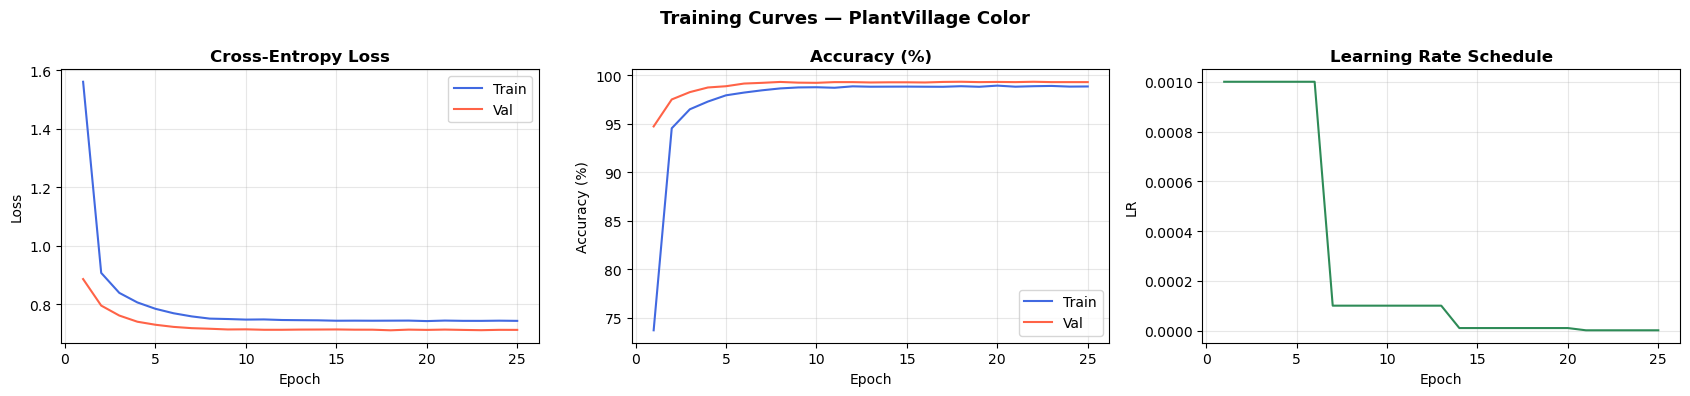

Saved → /kaggle/working/training_curves.png


In [17]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train", color="royalblue")
axes[0].plot(epochs_range, history["val_loss"],   label="Val",   color="tomato")
axes[0].set_title("Cross-Entropy Loss", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, [a*100 for a in history["train_acc"]],
             label="Train", color="royalblue")
axes[1].plot(epochs_range, [a*100 for a in history["val_acc"]],
             label="Val",   color="tomato")
axes[1].set_title("Accuracy (%)", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history["lr"], color="seagreen")
axes[2].set_title("Learning Rate Schedule", fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR")
axes[2].grid(alpha=0.3)

plt.suptitle("Training Curves — PlantVillage Color",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /kaggle/working/training_curves.png")

## 7. Evaluation on the Test Set

In [18]:
# ── Overall metrics ───────────────────────────────────────────────────────────
test_loss, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

macro_f1  = f1_score(test_labels,  test_preds, average="macro")
macro_pre = precision_score(test_labels, test_preds, average="macro", zero_division=0)
macro_rec = recall_score(test_labels,   test_preds, average="macro", zero_division=0)

print("=" * 45)
print(f"{'TEST RESULTS':^45}")
print("=" * 45)
print(f"  Loss             : {test_loss:.4f}")
print(f"  Overall Accuracy : {test_acc * 100:.2f}%")
print(f"  Macro Precision  : {macro_pre:.4f}")
print(f"  Macro Recall     : {macro_rec:.4f}")
print(f"  Macro F1 Score   : {macro_f1:.4f}")
print("=" * 45)

                TEST RESULTS                 
  Loss             : 0.7095
  Overall Accuracy : 99.32%
  Macro Precision  : 0.9922
  Macro Recall     : 0.9892
  Macro F1 Score   : 0.9906


In [19]:
# ── Per-class classification report ──────────────────────────────────────────
display_names = [c.replace("___", " — ").replace("_", " ") for c in CLASS_NAMES]
print(classification_report(
    test_labels, test_preds,
    target_names=display_names,
    digits=3
))

                                                    precision    recall  f1-score   support

                                Apple — Apple scab      1.000     0.986     0.993        72
                                 Apple — Black rot      1.000     1.000     1.000        64
                          Apple — Cedar apple rust      1.000     0.957     0.978        23
                                   Apple — healthy      1.000     1.000     1.000       169
                               Blueberry — healthy      1.000     1.000     1.000       130
          Cherry (including sour) — Powdery mildew      1.000     0.991     0.996       116
                 Cherry (including sour) — healthy      1.000     1.000     1.000        82
Corn (maize) — Cercospora leaf spot Gray leaf spot      0.955     0.933     0.944        45
                       Corn (maize) — Common rust       1.000     1.000     1.000       113
               Corn (maize) — Northern Leaf Blight      0.968     0.979     0.9

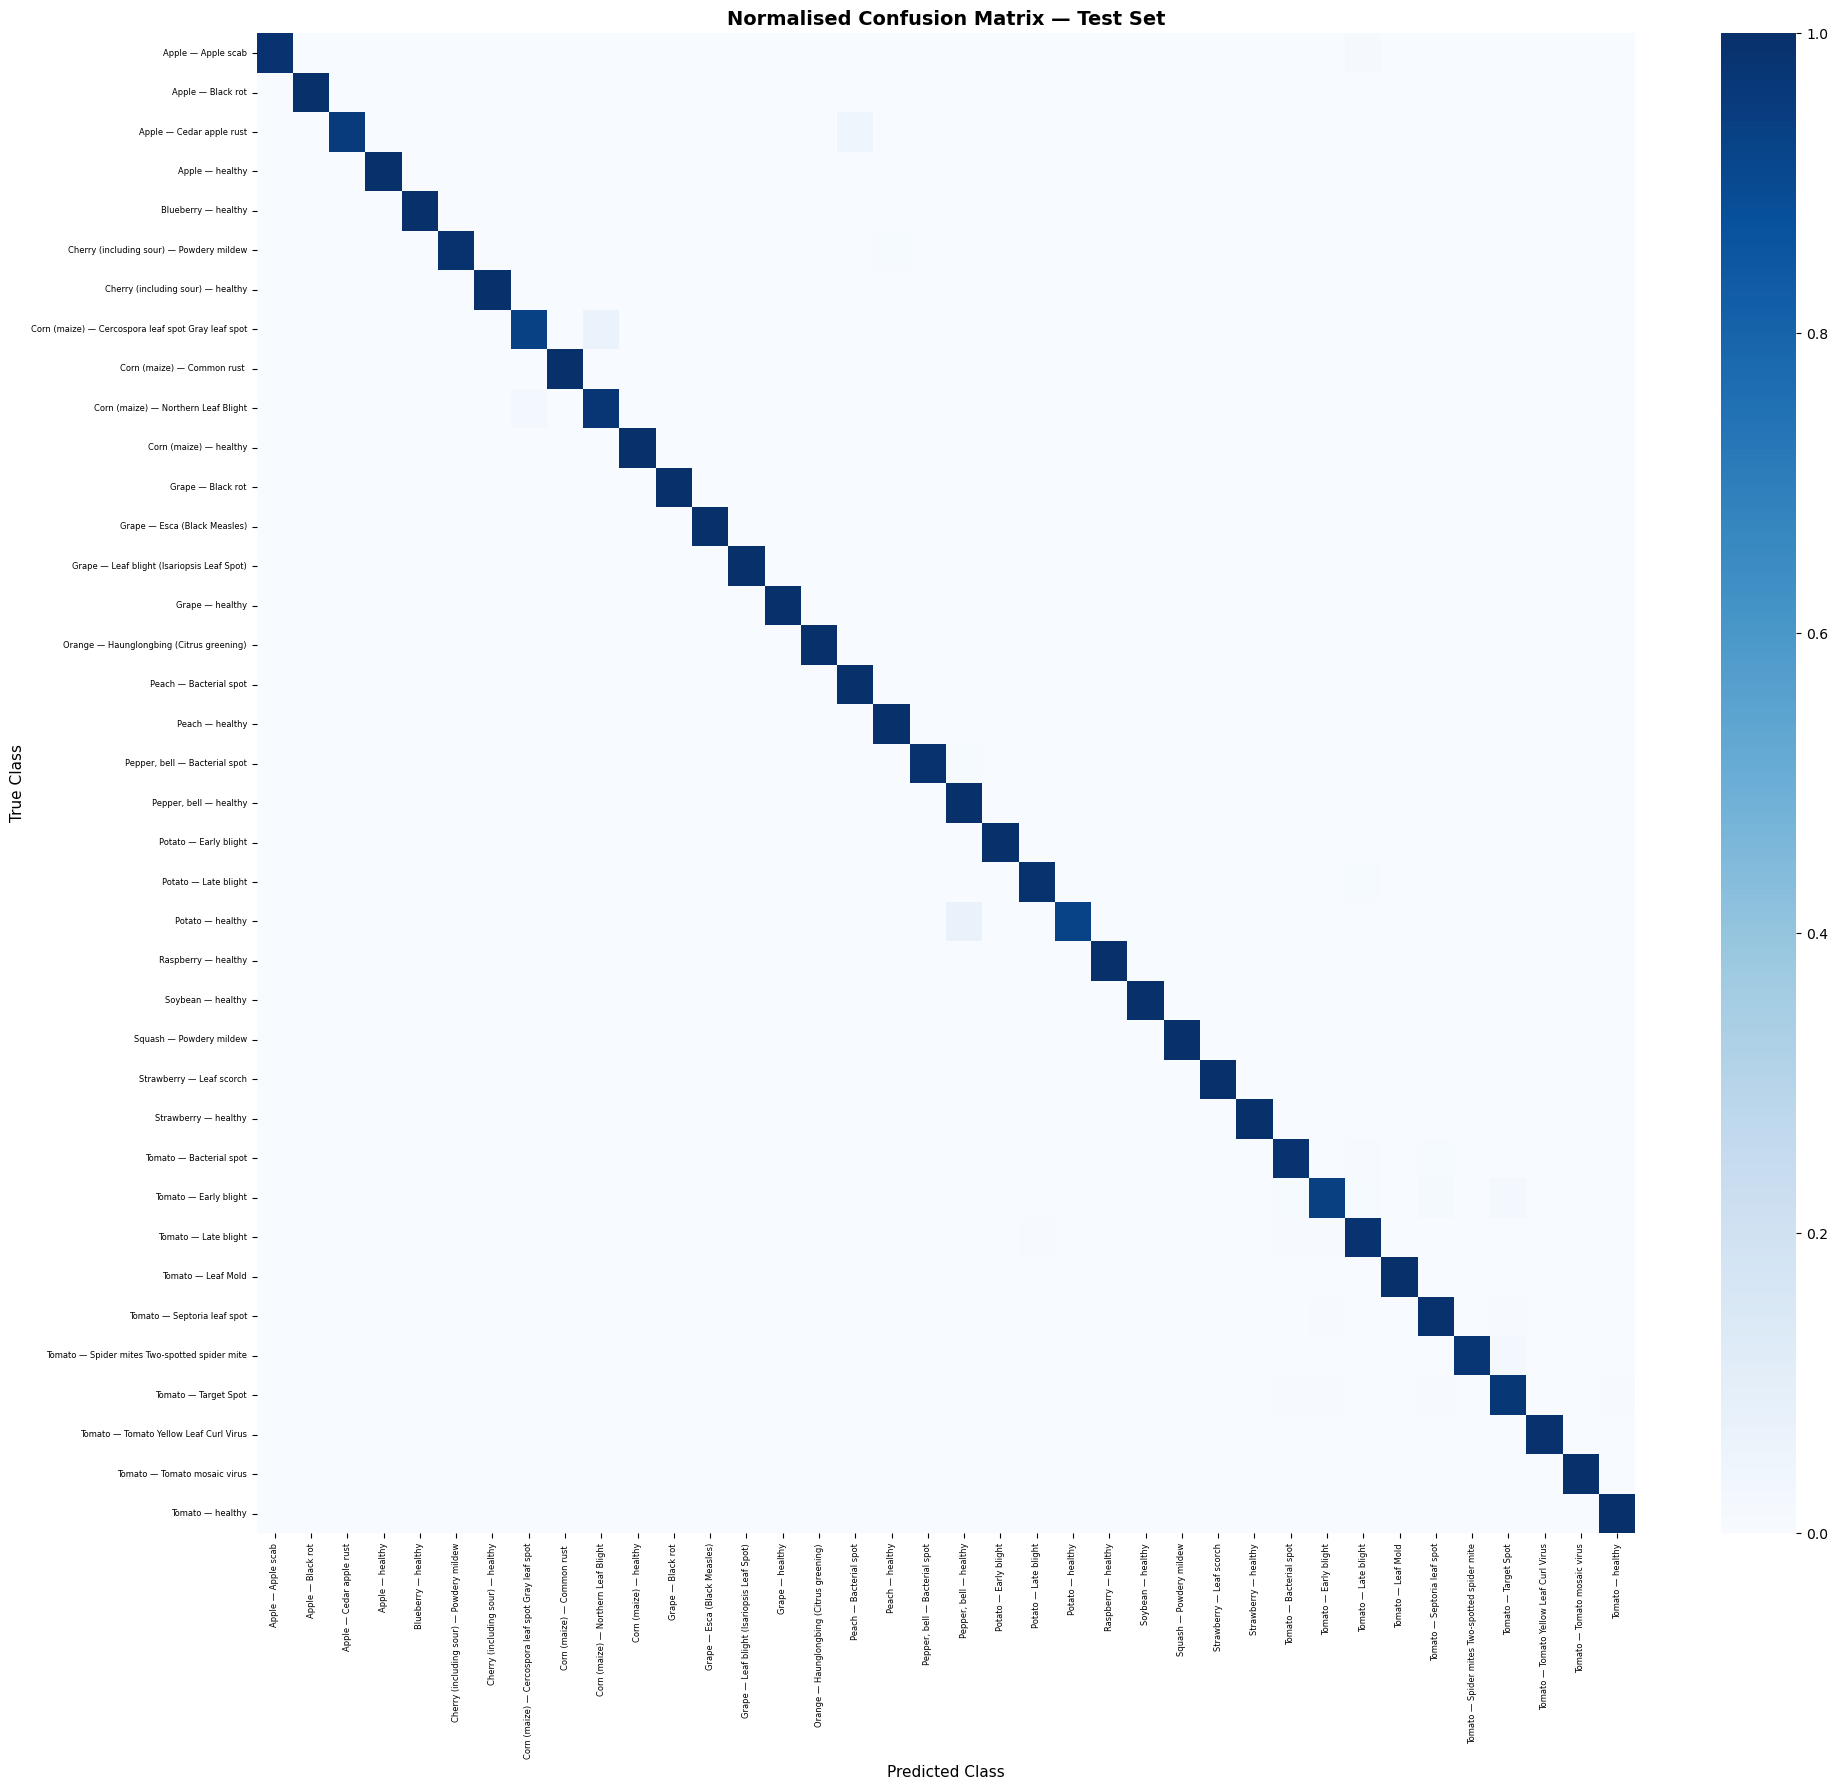

Saved → /kaggle/working/confusion_matrix.png


In [20]:
# ── Normalised Confusion Matrix ───────────────────────────────────────────────
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(
    cm_norm, annot=False, cmap="Blues",
    xticklabels=display_names, yticklabels=display_names,
    ax=ax, vmin=0, vmax=1
)
ax.set_title("Normalised Confusion Matrix — Test Set",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted Class", fontsize=11)
ax.set_ylabel("True Class", fontsize=11)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0,  fontsize=6)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /kaggle/working/confusion_matrix.png")

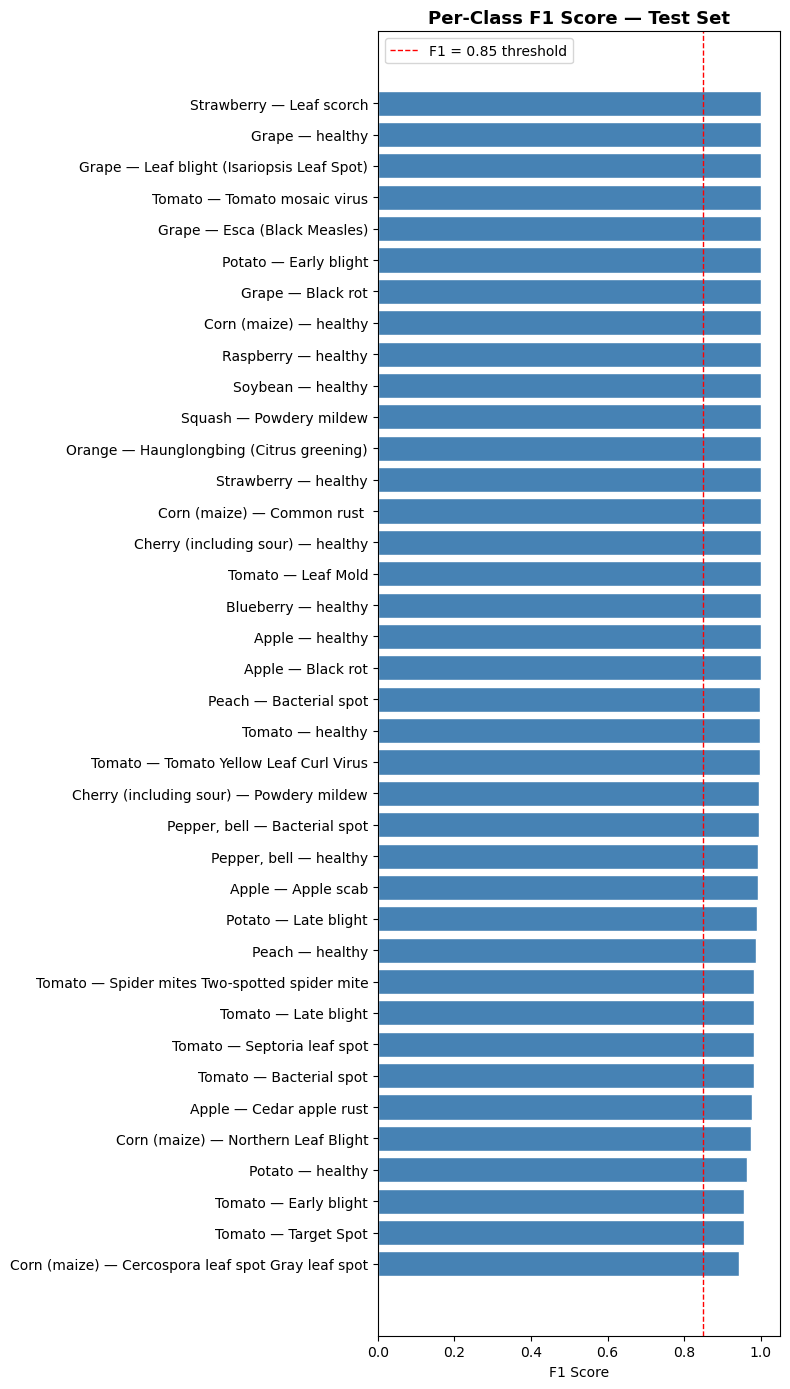

Saved → /kaggle/working/per_class_f1.png


In [21]:
# ── Per-class F1 bar chart ────────────────────────────────────────────────────
per_class_f1 = f1_score(test_labels, test_preds, average=None)
sorted_idx   = np.argsort(per_class_f1)
sorted_f1    = per_class_f1[sorted_idx]
sorted_names = [display_names[i] for i in sorted_idx]
colors = ["tomato" if f < 0.85 else "steelblue" for f in sorted_f1]

fig, ax = plt.subplots(figsize=(8, 14))
ax.barh(sorted_names, sorted_f1, color=colors, edgecolor="white")
ax.axvline(0.85, color="red", linestyle="--", linewidth=1,
           label="F1 = 0.85 threshold")
ax.set_xlabel("F1 Score")
ax.set_title("Per-Class F1 Score — Test Set", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /kaggle/working/per_class_f1.png")

In [22]:
class_dict = train_gen.class_indices
img_size = train_gen.image_shape
height = []
width = []
for _ in range(len(class_dict)):
    height.append(img_size[0])
    width.append(img_size[1])

Index_series = pd.Series(list(class_dict.values()), name= 'class_index')
Class_series = pd.Series(list(class_dict.keys()), name= 'class')
Height_series = pd.Series(height, name= 'height')
Width_series = pd.Series(width, name= 'width')
class_df = pd.concat([Index_series, Class_series, Height_series, Width_series], axis= 1)
csv_name = f'{subject}-class_dict.csv'
csv_save_loc = os.path.join(save_path, csv_name)
class_df.to_csv(csv_save_loc, index= False)
print(f'class csv file was saved as {csv_save_loc}')

NameError: name 'train_gen' is not defined

## 8. Inference on a Single Image

In [ ]:
def predict_image(image_path: str, model: nn.Module, class_names: list,
                  transform=eval_transform, device=DEVICE, top_k: int = 5):
    """
    Run inference on a single leaf image and display top-K predictions.
    """
    img    = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).squeeze().cpu().numpy()

    top_idx    = probs.argsort()[::-1][:top_k]
    top_probs  = probs[top_idx]
    top_labels = [class_names[i].replace("___", " — ").replace("_", " ")
                  for i in top_idx]

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(11, 4))
    ax_img.imshow(img)
    ax_img.set_title("Input Image", fontweight="bold")
    ax_img.axis("off")

    bar_colors = ["seagreen"] + ["steelblue"] * (top_k - 1)
    ax_bar.barh(top_labels[::-1], top_probs[::-1] * 100,
                color=bar_colors[::-1], edgecolor="white")
    ax_bar.set_xlabel("Confidence (%)")
    ax_bar.set_title(f"Top-{top_k} Predictions", fontweight="bold")
    ax_bar.set_xlim(0, 108)
    for i, v in enumerate(top_probs[::-1]):
        ax_bar.text(v * 100 + 1, i, f"{v*100:.1f}%", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f"Predicted : {top_labels[0]}  ({top_probs[0]*100:.2f}%)")
    return top_labels[0], top_probs[0]


# ── Demo: random image from test set ─────────────────────────────────────────
sample_idx  = random.choice(test_set.indices)
sample_path = full_dataset.samples[sample_idx][0]
true_label  = CLASS_NAMES[full_dataset.samples[sample_idx][1]]
print(f"True class : {true_label}")
predict_image(sample_path, model, CLASS_NAMES)

## 9. Save & Load Model

In [ ]:
SAVE_PATH = "/kaggle/working/plantvillage_color_model.pth"

torch.save({
    "model_state_dict" : model.state_dict(),
    "class_names"      : CLASS_NAMES,
    "num_classes"      : NUM_CLASSES,
    "architecture"     : "resnet50" if USE_PRETRAINED else "custom_cnn",
    "img_size"         : IMG_SIZE,
    "best_val_acc"     : best_val_acc,
    "test_acc"         : test_acc,
    "macro_f1"         : macro_f1,
    "history"          : history,
}, SAVE_PATH)

print(f"Model saved → {SAVE_PATH}")
print(f"  Architecture  : {'ResNet-50' if USE_PRETRAINED else 'CustomCNN'}")
print(f"  Best val acc  : {best_val_acc*100:.2f}%")
print(f"  Test accuracy : {test_acc*100:.2f}%")
print(f"  Macro F1      : {macro_f1:.4f}")

In [ ]:
# ── Reload helper ─────────────────────────────────────────────────────────────
def load_model(path: str, device=DEVICE):
    ckpt  = torch.load(path, map_location=device)
    arch  = ckpt["architecture"]
    n_cls = ckpt["num_classes"]
    m = build_resnet50(n_cls, fine_tune=False) if arch == "resnet50" \
        else CustomCNN(n_cls)
    m.load_state_dict(ckpt["model_state_dict"])
    m = m.to(device).eval()
    print(f"Loaded {arch} | "
          f"test_acc={ckpt['test_acc']*100:.2f}%  "
          f"macro_f1={ckpt['macro_f1']:.4f}")
    return m, ckpt["class_names"]

# Usage:
# loaded_model, loaded_classes = load_model("/kaggle/working/plantvillage_color_model.pth")

---
## Summary

| Item | Value |
|------|-------|
| Dataset | PlantVillage — Color |
| Total images | ~54,305 |
| Classes | 38 (14 crops × 26 disease states) |
| Architecture | ResNet-50 (Transfer Learning) |
| Split | 80 / 10 / 10 % |
| Optimizer | SGD (momentum=0.9, wd=1e-4) |
| Loss | Cross-Entropy (label smoothing=0.1) |
| Scheduler | StepLR (step=7, γ=0.1) |
| Epochs | 25 |
| Outputs saved | `best_model.pth`, `plantvillage_color_model.pth`, 3 plots |

**Next steps (Phase 2):**
- Repeat with **grayscale** and **segmented** splits  
- Compare CustomCNN vs. ResNet-50 results side-by-side  
- Grad-CAM activation maps to localise disease regions  
- Test on real-world field images

## **Thank You..**
If you find this notebook is good enough, please upvote it..